### Required Libaray Imports:

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Loading the Dataset:

In [3]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
df = data.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Exploratory Data Analysis(EDA) of the Dataset:

#### No.of training examples and Features of Dataset:

In [4]:
df.shape

(569, 31)

It shows that dataset has 569 training exmaples and 31 columns, out of which 30 are features and 1 is the target(label).

#### What are the features in the dataset?

In [5]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

#### Basic Information of the dataset:

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

Here, we can see that all the features are of dtype float64, which indicates that all features are numerical and continuous. The target label is discrete.

#### Basic Statistical Analysis:

In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


This gives the brief introduction of the dataset. Here, by looking at the mean of the features, we can access that we will require scaling of features beacuse there is the a lot of diffrence between the values of some features.

#### Class Wise Statistics:

In [8]:
df.groupby("target").mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
target,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


### Basic Visuals for understanding Data:

#### Histograms:

Histograms show the distribution of each numerical feature in the dataset. They help identify whether the data follows a normal distribution, is skewed, contains outliers, or has multiple peaks.

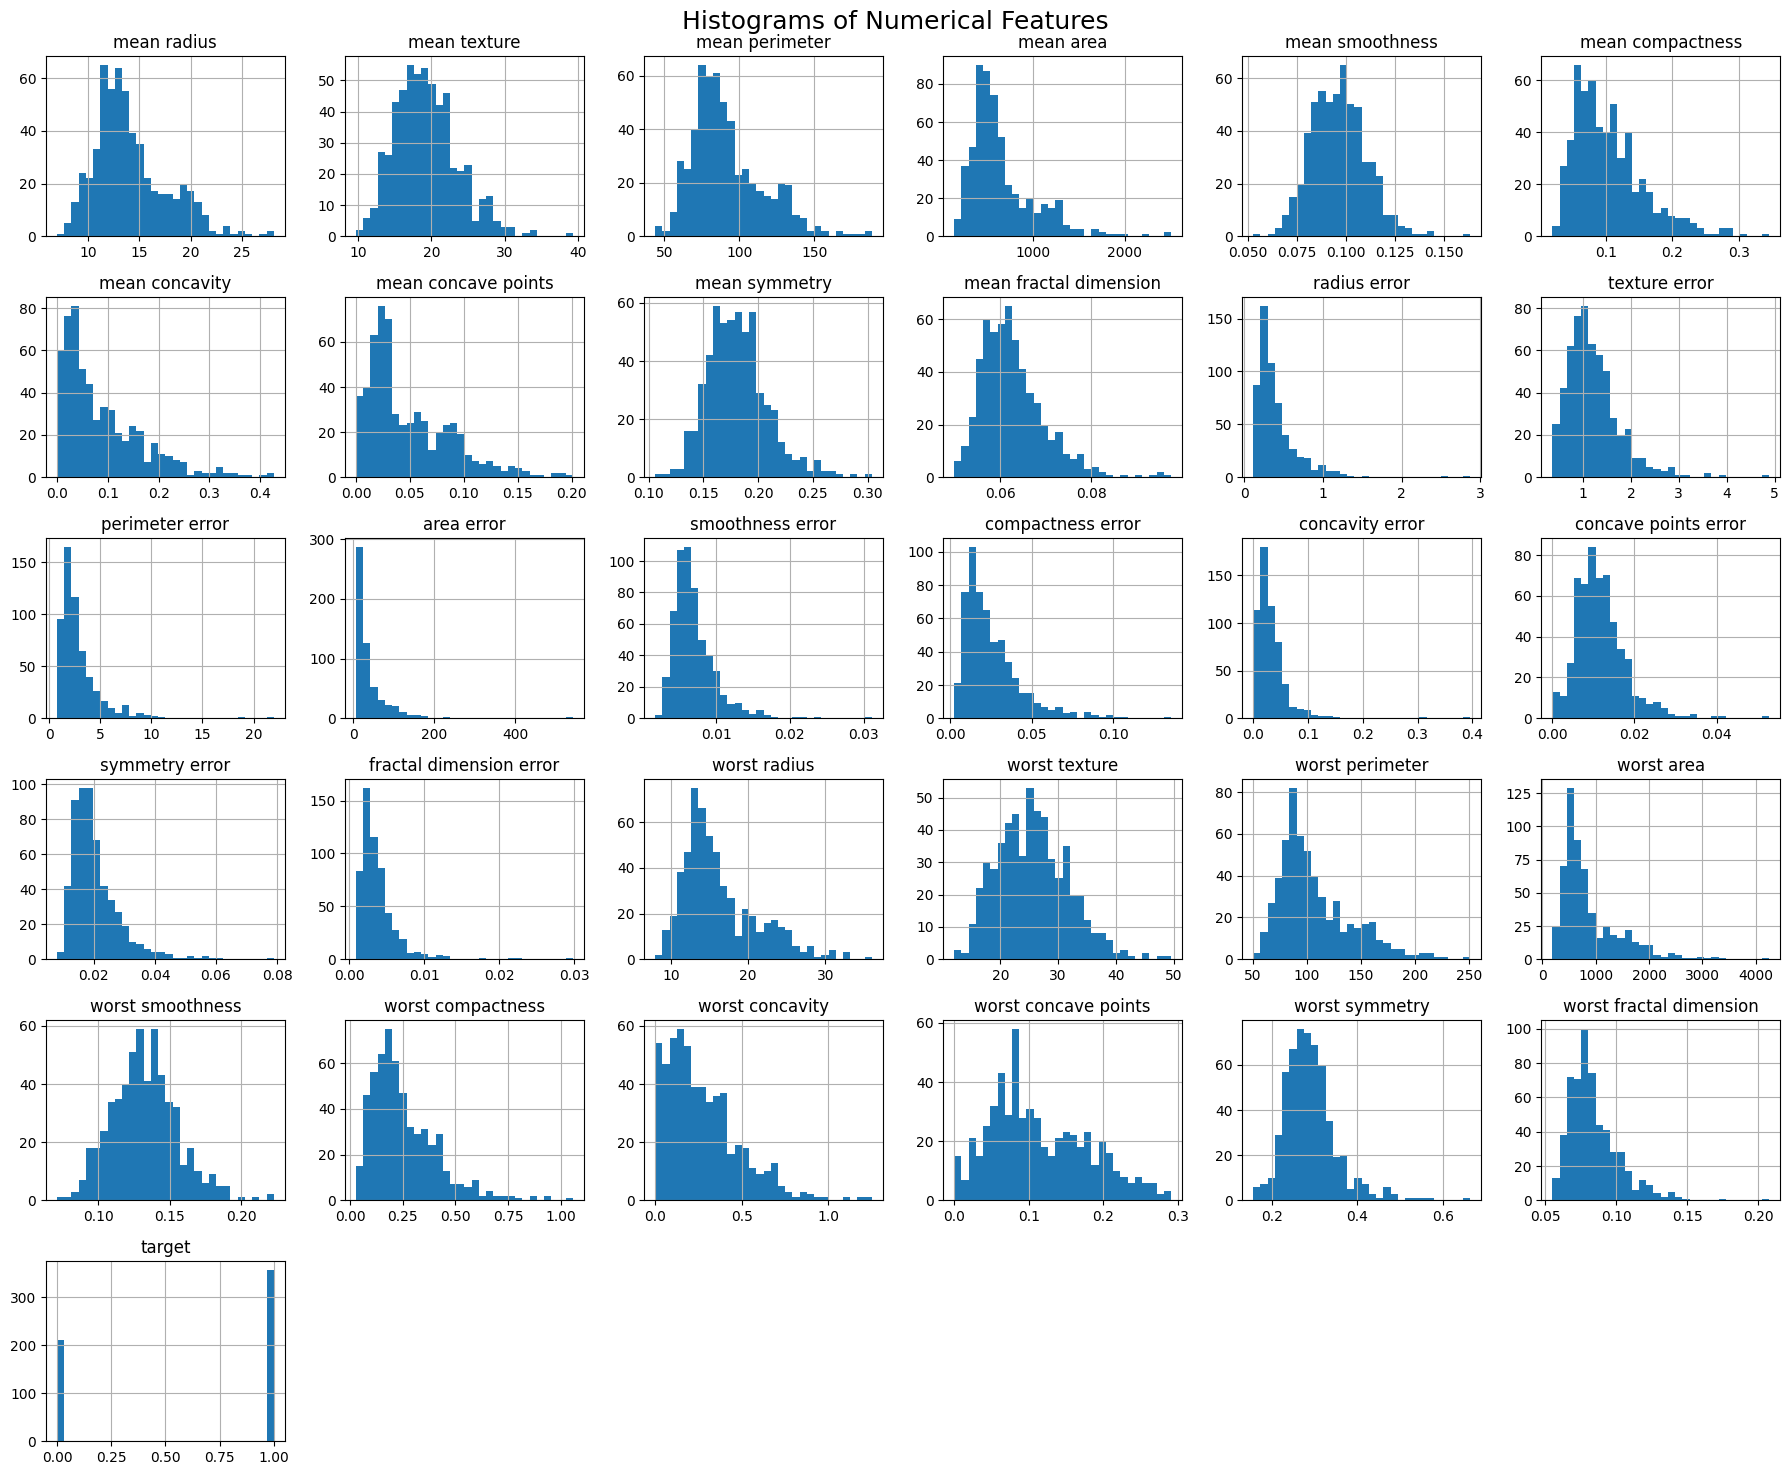

In [9]:
df.hist(figsize=(18, 15), bins=30)

plt.suptitle("Histograms of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

By looking at the histograms of the features, we can see that no feature is following the normal distribution.

#### Box Plots:

Box plots are useful for the detection of outliers.

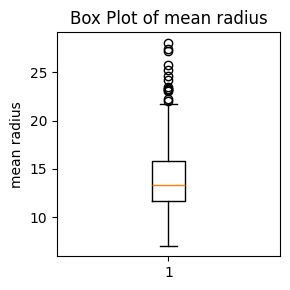

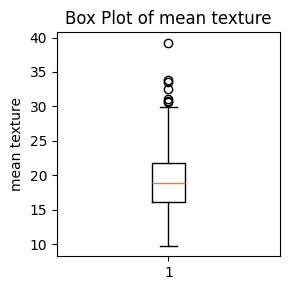

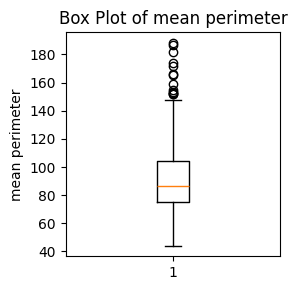

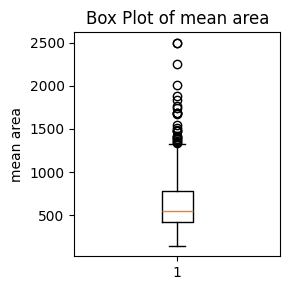

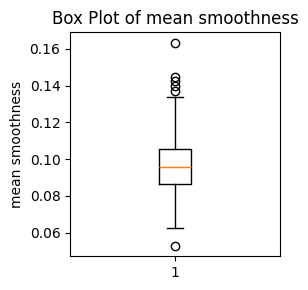

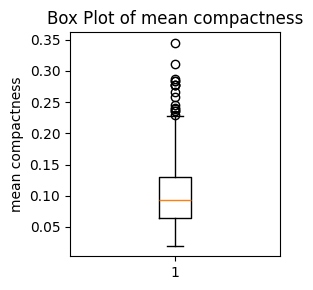

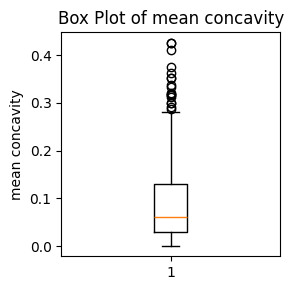

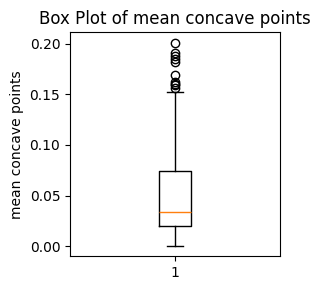

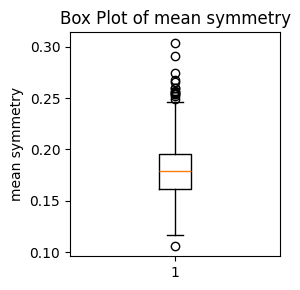

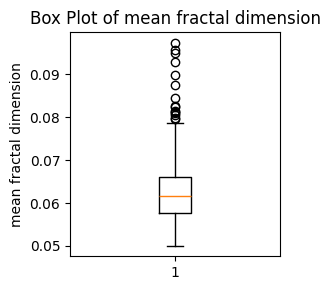

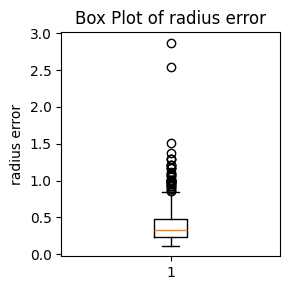

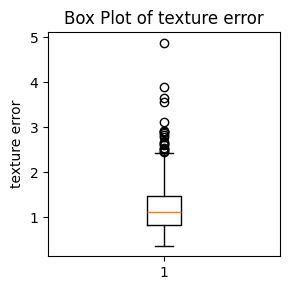

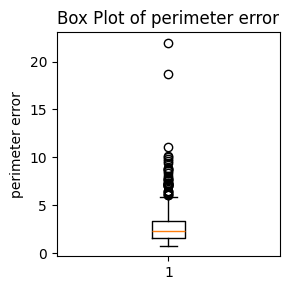

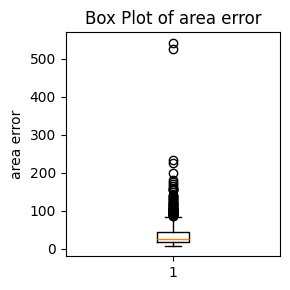

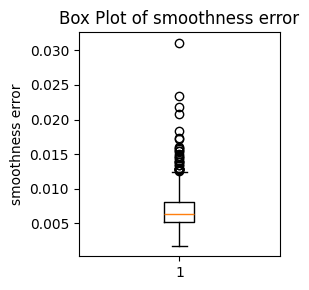

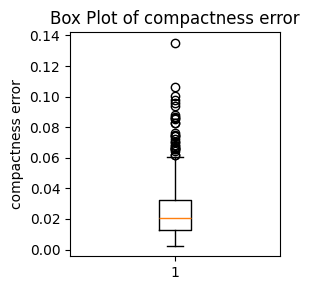

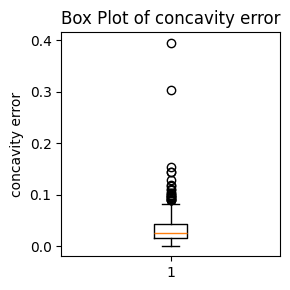

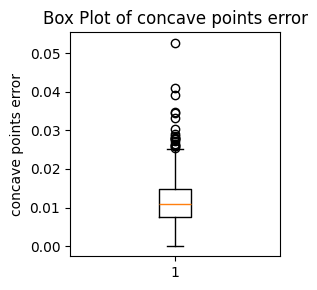

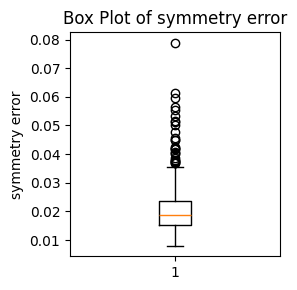

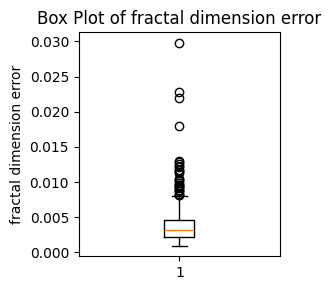

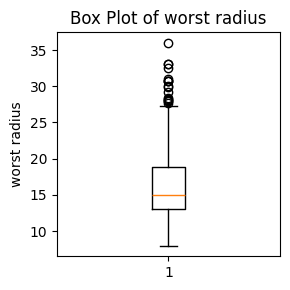

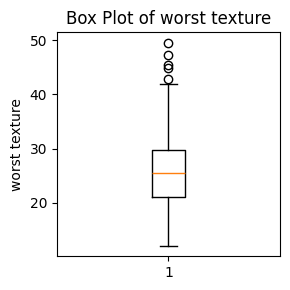

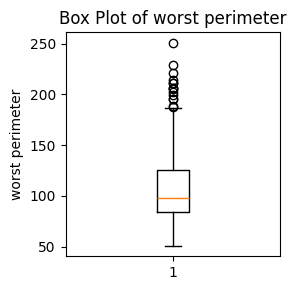

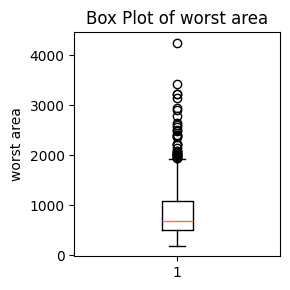

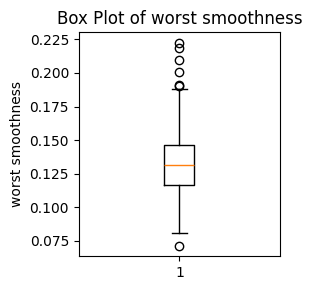

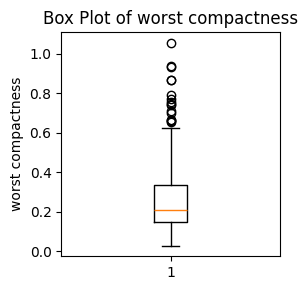

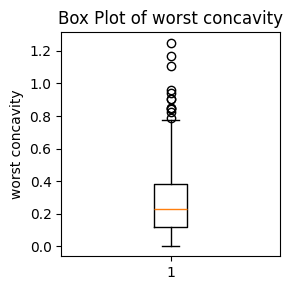

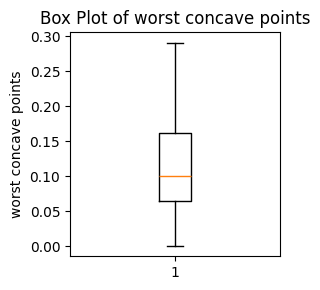

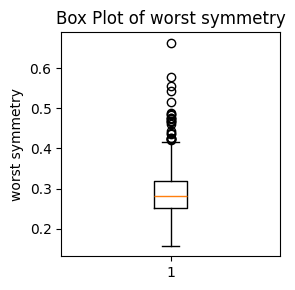

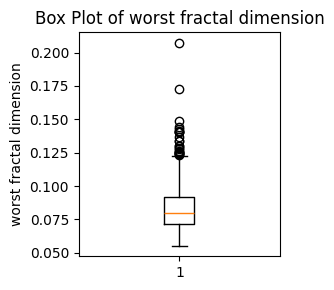

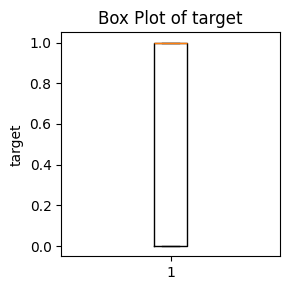

In [10]:
numerical_columns = df.select_dtypes(include=['number']).columns

for column in numerical_columns:
    plt.figure(figsize=(3, 3))

    plt.boxplot(df[column], vert=True)

    plt.title(f"Box Plot of {column}")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

#### Dealing with Outliers:

By Looking at the boxplots, we can access that majority of the features of the features have outliers. According to what I have learnt, we can deal with outliers in two ways:

1. By simply removing them.
2. By applying Robust scaling.
3. By just leaving Outliers as they are, because we are dealing with a medical dataset and in medical, the extreme values are possible.

#### Corelation Heatmap:

The corelation heatmap shows the corelation cofficient values which represents the corelation between the features. It is an important visual for determining multicolinearity between the features, also it is helpful for finding the best features of the dataset.

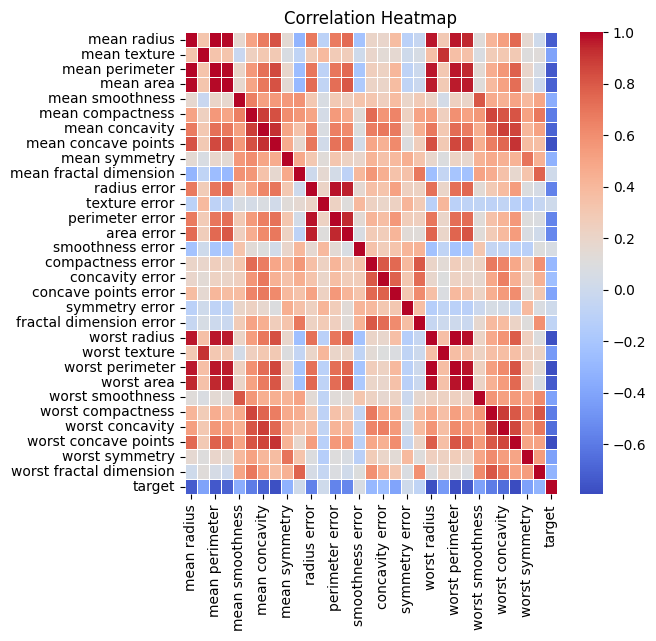

In [11]:
plt.figure(figsize=(6, 6))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

By looking at the corelation heatmap, we can see that muticolineraity exists between some features, but in this task, we will decision trees, random forest and XgBoost for classification tasks, so in this case, existance of multicolinearity does not effect the model performance.

#### Class Distribution Chart:

The class distribution chart shows the number of samples in each target class. It helps determine whether the dataset is balanced or imbalanced.

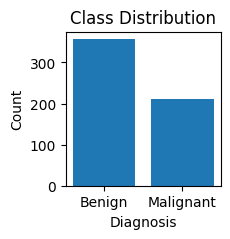

In [12]:
class_counts = df["target"].value_counts()

labels = ["Benign", "Malignant"]

plt.figure(figsize=(2,2))

plt.bar(labels, class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

#### Looking for Class Imbalance:

In [13]:
df["target"].value_counts() 

target
1    357
0    212
Name: count, dtype: int64

#### By Percentage:

In [14]:
df["target"].value_counts(1) * 100 

target
1    62.741652
0    37.258348
Name: proportion, dtype: float64

By these results, we can see that there is a class imbalance within a target label. To deal with class imbalance, I can recall two techniques.

1. Random Undersampling
2. Random Oversampling

#### Looking for Missing Values:

Now, we are looking for missing values in the dataset.

In [15]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

We can see that there are no missing values, so we dont need to handle them.

#### Looking For Duplicates:

In [16]:
df.duplicated().sum()

np.int64(0)

As we can see that there are no duplicate rows in the dataset, so we dont need to handle them.